# Quick MEM — 1D Mechanical Earth Model Workflow

End-to-end demo of **GeomechPy** following the standard MEM sequence, with a
**QC plot after every step** so each computed output can be inspected visually.

1. Data input (pandas)
2. Overburden stress
3. Lithology (toolbox)
4. Pore pressure
5. Dynamic elastic properties
6. Static elastic properties
7. Rock strength
8. Horizontal stresses + stress-tensor rotation
9. Wellbore stability (breakout / breakdown) — mud window in **ppg**
10. Master composite QC log

Stresses are reported in **psi**; the mud window is shown as equivalent mud
weight in **ppg**. Synthetic log data is generated so the notebook runs
without external files.

## 0. Setup & imports

In [1]:
import sys
from pathlib import Path

# repo root = two levels up from this notebook (example/Project/)
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "Project":
    REPO_ROOT = REPO_ROOT.parent.parent
elif REPO_ROOT.name == "example":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "example"))  # lithology in example/toolbox.py

import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import glob
import shutil
import plotly.io as pio


def _configure_plotly_renderer():
    """Embed a static PNG next to the interactive figure so plots show in
    every viewer (GitHub, nbviewer, JupyterLab, VS Code). Falls back to the
    interactive-only renderer when no Chrome/Chromium engine is available for
    static image export."""
    candidates = [os.environ.get("BROWSER_PATH")]
    candidates += [shutil.which(name) for name in
                   ("google-chrome", "google-chrome-stable", "chromium",
                    "chromium-browser", "chrome")]
    candidates += sorted(glob.glob("/opt/pw-browsers/chromium-*/chrome-linux/chrome"))
    for path in candidates:
        if path and os.path.exists(path):
            os.environ["BROWSER_PATH"] = path
            break
    try:
        import plotly.graph_objects as _go
        _go.Figure().to_image(format="png", width=200, height=200)
        pio.renderers.default = "plotly_mimetype+png"
    except Exception:
        pio.renderers.default = "plotly_mimetype+notebook_connected"


_configure_plotly_renderer()


# ---- QC plot helpers -------------------------------------------------------
LITH_COLORS = {0: "#E8C87D", 1: "#7F8C8D", 2: "#5DADE2", 6: "#1C1C1C"}
LITH_NAMES = {0: "Sand", 1: "Shale", 2: "Limestone", 6: "Coal"}


def depth_track(fig, col, series, color, name, row=1, dash=None, showlegend=True):
    fig.add_trace(
        go.Scatter(x=series, y=df["TVD"], mode="lines",
                   line=dict(color=color, dash=dash), name=name,
                   showlegend=showlegend),
        row=row, col=col,
    )


from geomechpy.overburden_stress import OverburdenStressCalculation
from geomechpy.pore_pressure import PorePressureCalculation
from geomechpy.elastic_properties import ElasticPropertiesConverter
from geomechpy.static_elastic_properties import StaticElasticPropertiesConverter
from geomechpy.rock_strength import RockStrengthPropertiesConverter
from geomechpy.stress_calculations import HorizontalStressesCalculation
from geomechpy.wellbore_stability import WellboreStabilityCalculation
from geomechpy.toolbox import rotate_stress_to_shmax, rotate_nev_to_toh
from toolbox import determine_lithology_array  # example/toolbox.py

print("Imports OK — repo root:", REPO_ROOT)
print("Plotly renderer:", pio.renderers.default)

Imports OK — repo root: /home/user/GeomechPy_smolrun
Plotly renderer: plotly_mimetype+png


## 1. Data input

Synthetic onshore well log (TVD 5 000 – 8 000 ft).

In [2]:
np.random.seed(42)
n = 61
tvd = np.linspace(5000.0, 8000.0, n)  # ft

# Synthetic curves with mild depth trends + noise
gr = 40 + 40 * np.sin(np.linspace(0, 4 * np.pi, n)) + np.random.normal(0, 5, n)  # gAPI
gr = np.clip(gr, 15, 140)

rhob = 2.35 + 0.00004 * (tvd - 5000) + np.random.normal(0, 0.02, n)  # g/cm3
dtco = 90 - 0.005 * (tvd - 5000) + np.random.normal(0, 2, n)       # us/ft
dtsh = 160 - 0.008 * (tvd - 5000) + np.random.normal(0, 3, n)      # us/ft
nphi = 0.18 - 0.00002 * (tvd - 5000) + np.random.normal(0, 0.01, n) # fraction
nphi = np.clip(nphi, 0.05, 0.30)

# Optional coal / limestone flags (mostly False)
coal_flag = [False] * n
limestone_flag = [False] * n
coal_flag[20] = True
limestone_flag[45] = True

df = pd.DataFrame({
    "TVD": tvd,
    "GR": gr,
    "RHOB": rhob,
    "DTCO": dtco,
    "DTSH": dtsh,
    "NPHI": nphi,
    "COAL": coal_flag,
    "LIME": limestone_flag,
})
df.head()

,TVD,GR,RHOB,DTCO,DTSH,NPHI,COAL,LIME
0,5000.0,42.483571,2.346287,92.805589,161.447417,0.167997,False,False
1,5050.0,47.625146,2.329873,86.946298,158.929612,0.175655,False,False
2,5100.0,59.507908,2.330076,90.673714,161.342001,0.173251,False,False
3,5150.0,71.126559,2.372251,93.630911,160.219713,0.170467,False,False
4,5200.0,68.555026,2.385125,87.018927,158.181513,0.193655,False,False


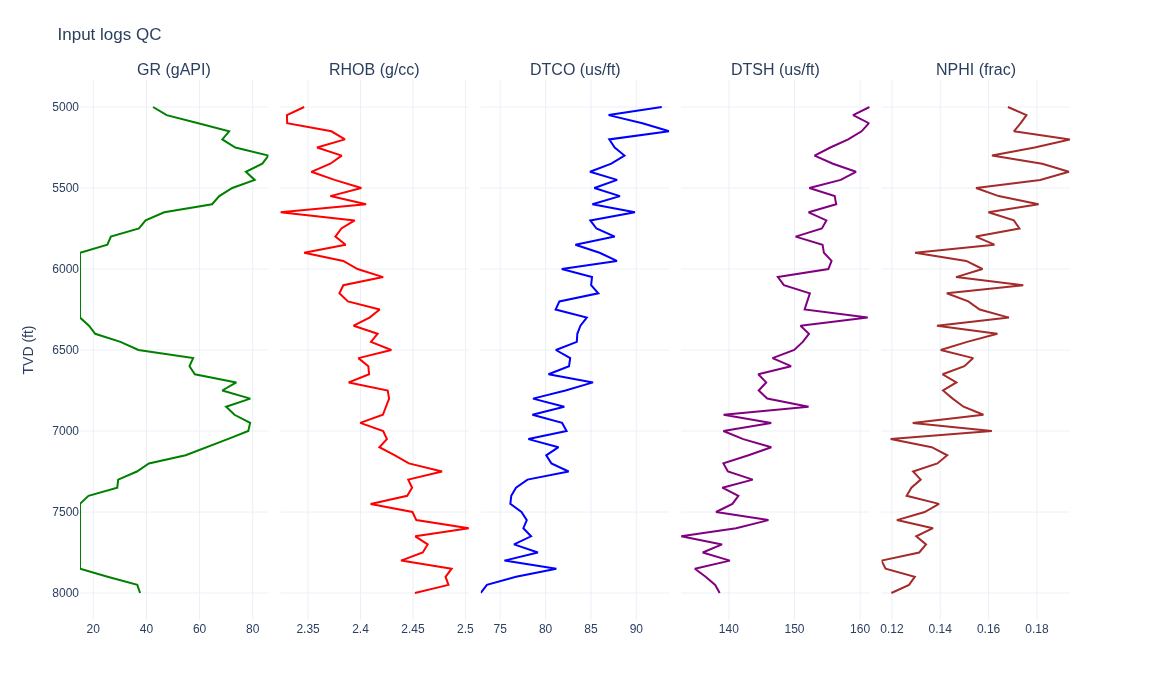

In [3]:
# QC — raw input logs vs depth
fig = make_subplots(rows=1, cols=5, shared_yaxes=True, horizontal_spacing=0.012,
                    subplot_titles=("GR (gAPI)", "RHOB (g/cc)", "DTCO (us/ft)",
                                    "DTSH (us/ft)", "NPHI (frac)"))
depth_track(fig, 1, df["GR"], "green", "GR", showlegend=False)
depth_track(fig, 2, df["RHOB"], "red", "RHOB", showlegend=False)
depth_track(fig, 3, df["DTCO"], "blue", "DTCO", showlegend=False)
depth_track(fig, 4, df["DTSH"], "purple", "DTSH", showlegend=False)
depth_track(fig, 5, df["NPHI"], "brown", "NPHI", showlegend=False)
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(height=700, width=1150, template="plotly_white",
                  title="Input logs QC", margin=dict(t=80))
fig.show()

## 2. Overburden stress (onshore)

In [4]:
AIR_GAP = 30.0  # ft KB to ground
LITHOSTATIC_GRAD = 1.05  # psi/ft

df["SV"] = OverburdenStressCalculation.calculate_overburden_stress_onshore_array(
    tvd=df["TVD"].tolist(),
    lithostatic_gradient=LITHOSTATIC_GRAD,
    air_gap=AIR_GAP,
)
df[["TVD", "SV"]].head()

,TVD,SV
0,5000.0,5218.512
1,5050.0,5271.012
2,5100.0,5323.512
3,5150.0,5376.012
4,5200.0,5428.512


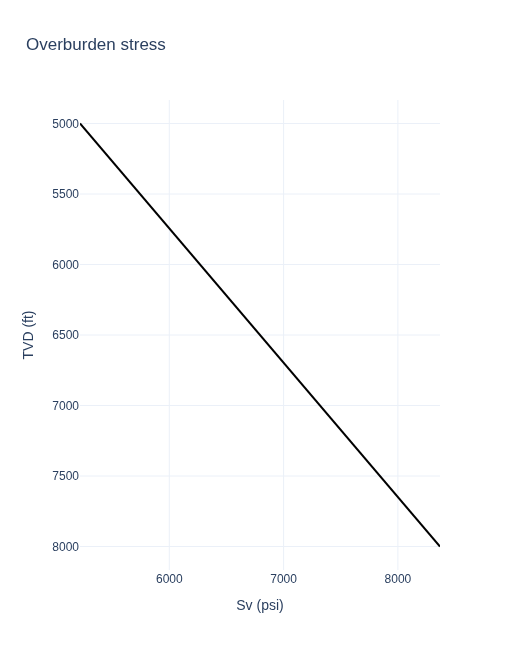

In [5]:
# QC — overburden stress (psi)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df["SV"], y=df["TVD"], mode="lines",
                         line=dict(color="black"), name="Sv"))
fig.update_yaxes(autorange="reversed", title="TVD (ft)")
fig.update_layout(height=650, width=520, template="plotly_white",
                  title="Overburden stress", xaxis_title="Sv (psi)")
fig.show()

## 3. Lithology (mechanical stratigraphy from GR)

In [6]:
df["LITH"] = determine_lithology_array(
    gamma_ray=df["GR"].tolist(),
    gr_threshold=75.0,
    coal_flag=df["COAL"].tolist(),
    limestone_flag=df["LIME"].tolist(),
)
# 0=Sand, 1=Shale, 2=Limestone, 6=Coal
df["LITH_NAME"] = df["LITH"].map({0: "Sand", 1: "Shale", 2: "Limestone", 6: "Coal"})
df[["TVD", "GR", "LITH", "LITH_NAME"]].value_counts("LITH_NAME")

LITH_NAME
Sand         52
Shale         7
Coal          1
Limestone     1
Name: count, dtype: int64

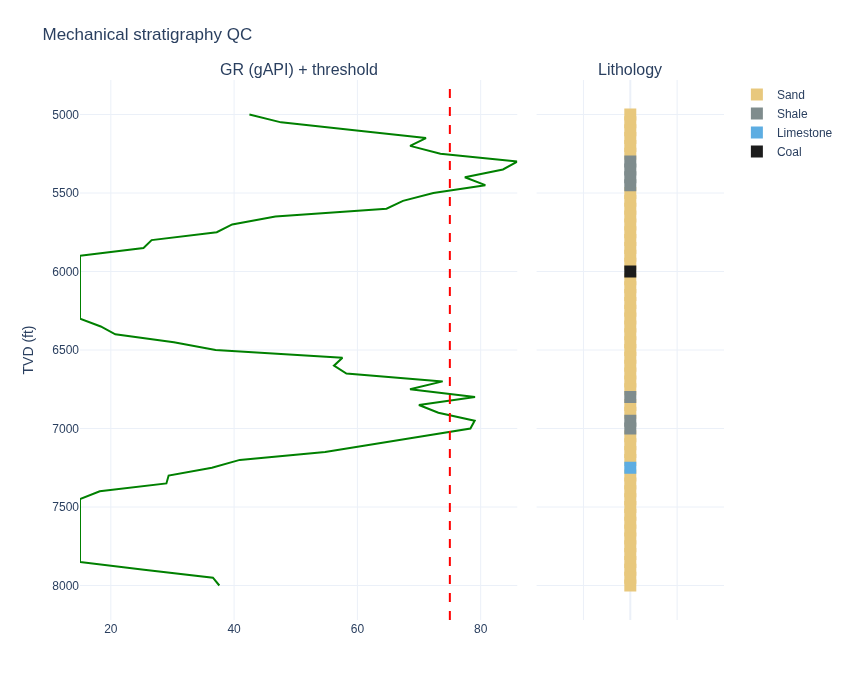

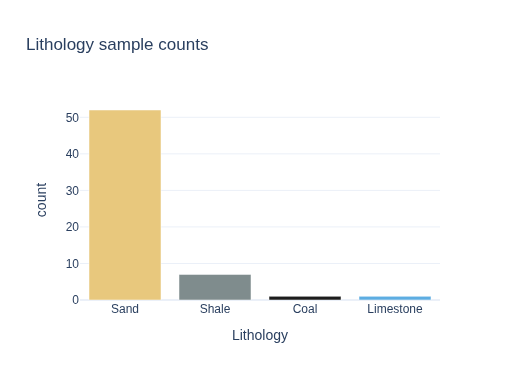

In [7]:
# QC — lithology from GR (threshold = 75 gAPI)
GR_THRESHOLD = 75.0
fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.03,
                    column_widths=[0.7, 0.3],
                    subplot_titles=("GR (gAPI) + threshold", "Lithology"))

fig.add_trace(go.Scatter(x=df["GR"], y=df["TVD"], mode="lines",
                         line=dict(color="green"), name="GR", showlegend=False),
              row=1, col=1)
fig.add_vline(x=GR_THRESHOLD, line=dict(color="red", dash="dash"), row=1, col=1)

# lithology as coloured markers per depth sample
for code, name in LITH_NAMES.items():
    m = df["LITH"] == code
    if m.any():
        fig.add_trace(go.Scatter(x=[0] * int(m.sum()), y=df.loc[m, "TVD"],
                                 mode="markers",
                                 marker=dict(color=LITH_COLORS[code], size=12,
                                             symbol="square"),
                                 name=name), row=1, col=2)

fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_xaxes(showticklabels=False, range=[-1, 1], row=1, col=2)
fig.update_layout(height=700, width=850, template="plotly_white",
                  title="Mechanical stratigraphy QC", margin=dict(t=80))
fig.show()

# lithology sample counts
counts = df["LITH_NAME"].value_counts()
figc = go.Figure(go.Bar(x=counts.index, y=counts.values,
                        marker_color=[LITH_COLORS[{v: k for k, v in LITH_NAMES.items()}[n]]
                                      for n in counts.index]))
figc.update_layout(height=380, width=520, template="plotly_white",
                   title="Lithology sample counts",
                   xaxis_title="Lithology", yaxis_title="count")
figc.show()

## 4. Pore pressure (onshore hydrostatic)

In [8]:
PP_GRAD = 0.465  # psi/ft

df["PP"] = PorePressureCalculation.calculate_pore_pressure_onshore_array(
    tvd=df["TVD"].tolist(),
    formation_pore_pressure_gradient=PP_GRAD,
    air_gap=AIR_GAP,
)
df[["TVD", "PP"]].head()

,TVD,PP
0,5000.0,2311.062
1,5050.0,2334.312
2,5100.0,2357.562
3,5150.0,2380.812
4,5200.0,2404.062


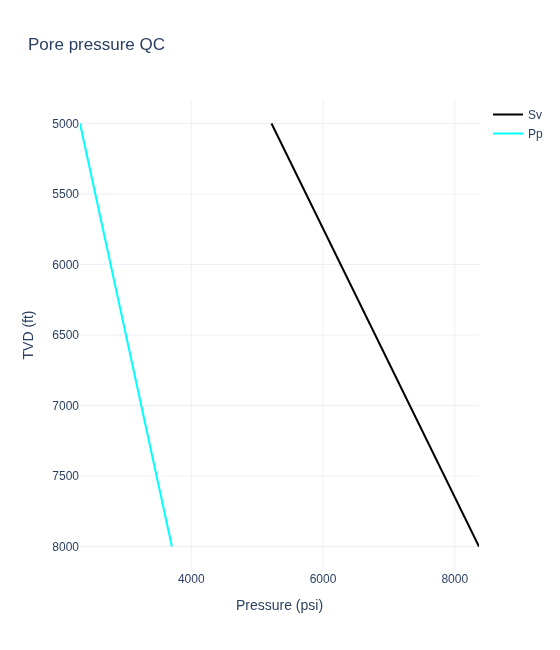

In [9]:
# QC — pore pressure vs overburden (psi)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df["SV"], y=df["TVD"], mode="lines",
                         line=dict(color="black"), name="Sv"))
fig.add_trace(go.Scatter(x=df["PP"], y=df["TVD"], mode="lines",
                         line=dict(color="cyan"), name="Pp"))
fig.update_yaxes(autorange="reversed", title="TVD (ft)")
fig.update_layout(height=650, width=560, template="plotly_white",
                  title="Pore pressure QC", xaxis_title="Pressure (psi)")
fig.show()

## 5. Dynamic elastic properties

From compressional / shear slowness + bulk density.

In [10]:
# density must be kg/m3 for the converter
density_kgm3 = (df["RHOB"] * 1000).tolist()

dyn_props = ElasticPropertiesConverter.convert_dynamic_elastic_properties_from_slowness_array(
    p_wave_slowness=df["DTCO"].tolist(),
    s_wave_slowness=df["DTSH"].tolist(),
    density=density_kgm3,
)

df["YME_DYN_Pa"] = [p.youngs_modulus for p in dyn_props]
df["PR_DYN"] = [p.poissons_ratio for p in dyn_props]
df["G_DYN_Pa"] = [p.shear_modulus for p in dyn_props]

# Convert Pa to Mpsi for static correlations that expect Mpsi
PA_TO_MPSI = 1.0 / 6.894757e9
df["YME_DYN_Mpsi"] = df["YME_DYN_Pa"] * PA_TO_MPSI
df["G_DYN_GPa"] = df["G_DYN_Pa"] / 1e9
df[["TVD", "YME_DYN_Mpsi", "PR_DYN", "G_DYN_GPa"]].head()

,TVD,YME_DYN_Mpsi,PR_DYN,G_DYN_GPa
0,5000.0,3.040159,0.253246,8.362744
1,5050.0,3.197808,0.286438,8.569443
2,5100.0,3.061527,0.269176,8.315821
3,5150.0,3.089803,0.240684,8.585361
4,5200.0,3.295894,0.283018,8.855836


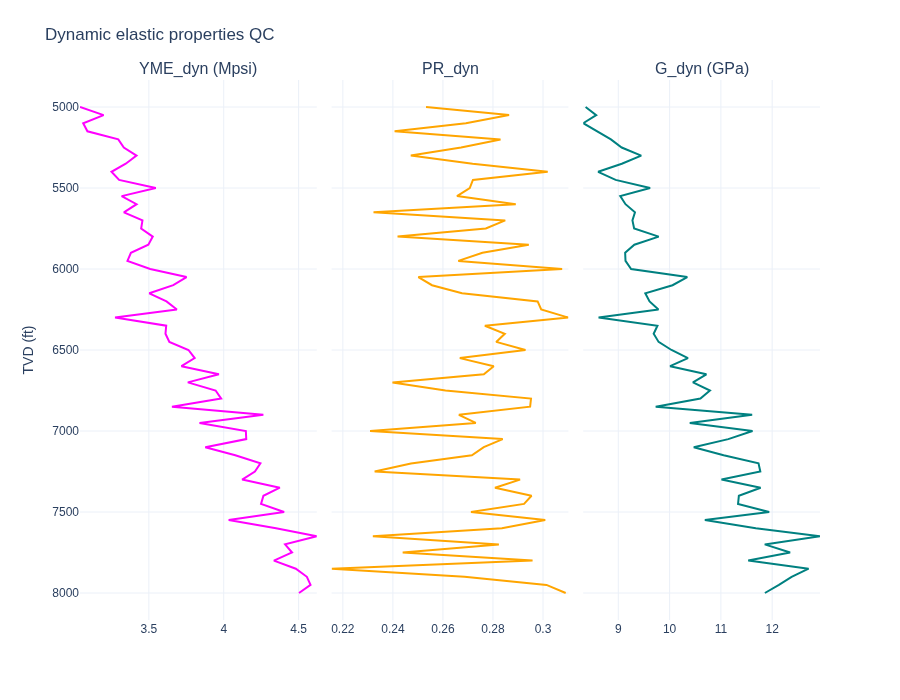

In [11]:
# QC — dynamic elastic properties
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, horizontal_spacing=0.02,
                    subplot_titles=("YME_dyn (Mpsi)", "PR_dyn", "G_dyn (GPa)"))
depth_track(fig, 1, df["YME_DYN_Mpsi"], "magenta", "YME_dyn", showlegend=False)
depth_track(fig, 2, df["PR_DYN"], "orange", "PR_dyn", showlegend=False)
depth_track(fig, 3, df["G_DYN_GPa"], "teal", "G_dyn", showlegend=False)
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(height=700, width=900, template="plotly_white",
                  title="Dynamic elastic properties QC", margin=dict(t=80))
fig.show()

## 6. Static elastic properties

Bradford correlation (dynamic to static YME) + PR scaling.

In [12]:
df["YME_STA_Mpsi"] = StaticElasticPropertiesConverter.dyn2sta_yme_bradord_array(
    yme_dyn=df["YME_DYN_Mpsi"].tolist()
)
df["PR_STA"] = StaticElasticPropertiesConverter.dyn2sta_poissons_ratio_array(
    pr_dyn=df["PR_DYN"].tolist(),
    multiplier=1.0,
)
df["BIOT"] = [
    StaticElasticPropertiesConverter.biot_coefficient_constant_law(1.0)
    for _ in range(len(df))
]
df[["TVD", "YME_STA_Mpsi", "PR_STA", "BIOT"]].head()

,TVD,YME_STA_Mpsi,PR_STA,BIOT
0,5000.0,0.965106,0.253246,1.0
1,5050.0,1.106258,0.286438,1.0
2,5100.0,0.983530,0.269176,1.0
3,5150.0,1.008250,0.240684,1.0
4,5200.0,1.200280,0.283018,1.0


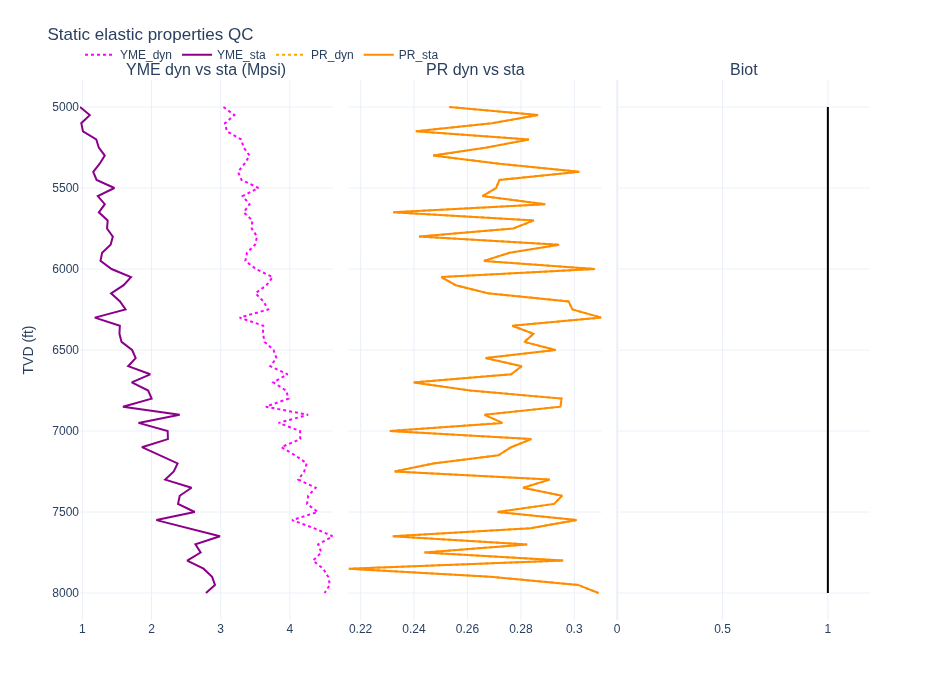

In [13]:
# QC — dynamic vs static elastic properties
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, horizontal_spacing=0.02,
                    subplot_titles=("YME dyn vs sta (Mpsi)", "PR dyn vs sta", "Biot"))
depth_track(fig, 1, df["YME_DYN_Mpsi"], "magenta", "YME_dyn", dash="dot")
depth_track(fig, 1, df["YME_STA_Mpsi"], "darkmagenta", "YME_sta")
depth_track(fig, 2, df["PR_DYN"], "orange", "PR_dyn", dash="dot")
depth_track(fig, 2, df["PR_STA"], "darkorange", "PR_sta")
depth_track(fig, 3, df["BIOT"], "black", "Biot", showlegend=False)
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_xaxes(range=[0, 1.2], row=1, col=3)
fig.update_layout(height=700, width=950, template="plotly_white",
                  title="Static elastic properties QC", margin=dict(t=80),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02))
fig.show()

## 7. Rock strength (UCS, tensile strength, friction angle)

In [14]:
df["UCS"] = RockStrengthPropertiesConverter.convert_yme_sta_to_ucs_plumb_array(
    yme_sta=df["YME_STA_Mpsi"].tolist()
)
df["TSTR"] = RockStrengthPropertiesConverter.convert_ucs_to_tstr_array(
    ucs=df["UCS"].tolist(),
    multiplier=0.15,
)
df["FANG"] = RockStrengthPropertiesConverter.convert_friction_angle_lal_array(
    dtco=df["DTCO"].tolist()
)
df[["TVD", "UCS", "TSTR", "FANG"]].head()

,TVD,UCS,TSTR,FANG
0,5000.0,0.202968,0.030445,32.220415
1,5050.0,0.232653,0.034898,33.787152
2,5100.0,0.206843,0.031026,32.781899
3,5150.0,0.212042,0.031806,32.005581
4,5200.0,0.252427,0.037864,33.767269


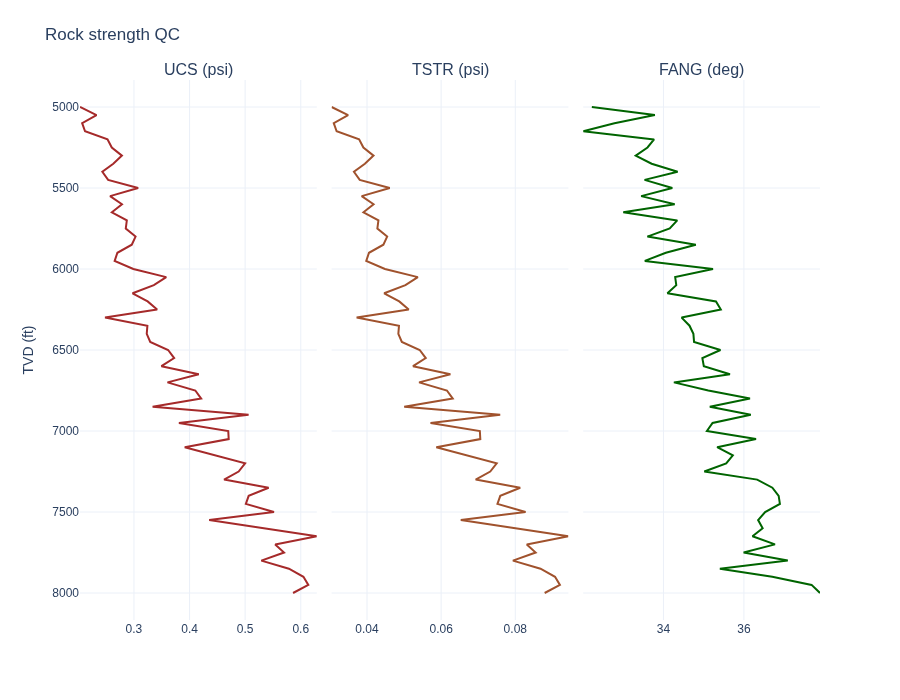

In [15]:
# QC — rock strength (UCS & tensile strength in psi, friction angle in deg)
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, horizontal_spacing=0.02,
                    subplot_titles=("UCS (psi)", "TSTR (psi)", "FANG (deg)"))
depth_track(fig, 1, df["UCS"], "brown", "UCS", showlegend=False)
depth_track(fig, 2, df["TSTR"], "sienna", "TSTR", showlegend=False)
depth_track(fig, 3, df["FANG"], "darkgreen", "FANG", showlegend=False)
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(height=700, width=900, template="plotly_white",
                  title="Rock strength QC", margin=dict(t=80))
fig.show()

## 8. Horizontal stresses (poroelastic) + stress-tensor rotation

In [16]:
hs_list = HorizontalStressesCalculation.calculate_poroelastic_horizontal_stresses_array(
    overburden_stress=df["SV"].tolist(),
    pore_pressure=df["PP"].tolist(),
    poisson_ratio=df["PR_STA"].tolist(),
    youngs_modulus=df["YME_STA_Mpsi"].tolist(),
    biot_coefficient=df["BIOT"].tolist(),
    EX=0.0001,
    EY=0.0005,
)
df["SHMIN"] = [h.shmin for h in hs_list]
df["SHMAX"] = [h.shmax for h in hs_list]
df["Q_FACTOR"] = [h.q_factor for h in hs_list]
df["SHMAX_SHMIN_RATIO"] = [h.shmax_shmin_ratio for h in hs_list]

# Example rotation at mid-depth
mid = len(df) // 2
SHMAX_AZIMUTH = 45.0  # deg from North
stress_nev = rotate_stress_to_shmax(
    shmin=df["SHMIN"].iloc[mid],
    shmax=df["SHMAX"].iloc[mid],
    svert=df["SV"].iloc[mid],
    shmax_azimuth=SHMAX_AZIMUTH,
)
print("Stress tensor NEV at mid-depth (psi):")
print(np.round(stress_nev, 1))
df[["TVD", "SHMIN", "SHMAX", "Q_FACTOR"]].head()

Stress tensor NEV at mid-depth (psi):
[[4.5779e+03 3.0000e-01 0.0000e+00]
 [3.0000e-01 4.5779e+03 0.0000e+00]
 [0.0000e+00 0.0000e+00 6.7935e+03]]


,TVD,SHMIN,SHMAX,Q_FACTOR
0,5000.0,3297.299162,3297.607196,2.999907
1,5050.0,3513.453854,3513.797830,2.999902
2,5100.0,3450.226000,3450.535974,2.999910
3,5150.0,3330.451351,3330.776414,2.999902
4,5200.0,3598.231561,3598.605766,2.999896


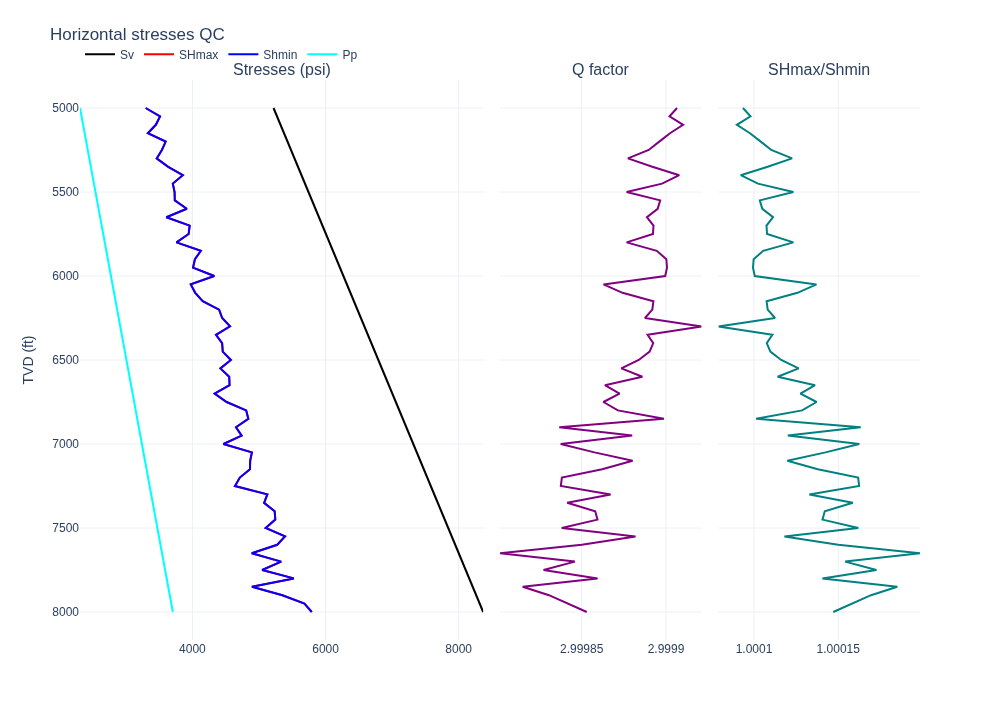

In [17]:
# QC — stress profile (psi) + stress ratios
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, horizontal_spacing=0.02,
                    column_widths=[0.5, 0.25, 0.25],
                    subplot_titles=("Stresses (psi)", "Q factor", "SHmax/Shmin"))
depth_track(fig, 1, df["SV"], "black", "Sv")
depth_track(fig, 1, df["SHMAX"], "red", "SHmax")
depth_track(fig, 1, df["SHMIN"], "blue", "Shmin")
depth_track(fig, 1, df["PP"], "cyan", "Pp")
depth_track(fig, 2, df["Q_FACTOR"], "purple", "Q", showlegend=False)
depth_track(fig, 3, df["SHMAX_SHMIN_RATIO"], "teal", "ratio", showlegend=False)
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(height=720, width=1000, template="plotly_white",
                  title="Horizontal stresses QC", margin=dict(t=80),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02))
fig.show()

## 9. Wellbore stability (vertical well)

Breakout (Mohr-Coulomb) and breakdown (tensile) pressures, converted to an equivalent mud weight window in ppg.

In [18]:
df["PW_BREAKOUT"] = (
    WellboreStabilityCalculation
    .calculate_breakout_calculation_vertical_well_mohr_coulomb_analytical_array(
        shmax=df["SHMAX"].tolist(),
        shmin=df["SHMIN"].tolist(),
        pprs=df["PP"].tolist(),
        overburden_stress=df["SV"].tolist(),
        ucs=df["UCS"].tolist(),
        fang=df["FANG"].tolist(),
        pr_sta=df["PR_STA"].tolist(),
    )
)
df["PW_BREAKDOWN"] = (
    WellboreStabilityCalculation
    .calculate_breakdown_calculation_vertical_well_analytical_array(
        shmax=df["SHMAX"].tolist(),
        shmin=df["SHMIN"].tolist(),
        pprs=df["PP"].tolist(),
        tstr=df["TSTR"].tolist(),
    )
)

# Convert critical wellbore pressures (psi) to equivalent mud weight (ppg)
# ppg = pressure_psi / (0.052 * TVD_ft)
PSI_PER_PPG_FT = 0.052
df["PP_PPG"] = df["PP"] / (PSI_PER_PPG_FT * df["TVD"])
df["MW_BREAKOUT_PPG"] = df["PW_BREAKOUT"] / (PSI_PER_PPG_FT * df["TVD"])
df["MW_BREAKDOWN_PPG"] = df["PW_BREAKDOWN"] / (PSI_PER_PPG_FT * df["TVD"])
df[["TVD", "PW_BREAKOUT", "PW_BREAKDOWN", "PP",
    "MW_BREAKOUT_PPG", "MW_BREAKDOWN_PPG", "PP_PPG"]].head()

,TVD,PW_BREAKOUT,PW_BREAKDOWN,PP,MW_BREAKOUT_PPG,MW_BREAKDOWN_PPG,PP_PPG
0,5000.0,3196.308643,4283.258735,2311.062,12.293495,16.474072,8.888700
1,5050.0,3172.015486,4692.286631,2334.312,12.079267,17.868571,8.889231
2,5100.0,3239.878281,4542.611052,2357.562,12.216736,17.129001,8.889751
3,5150.0,3300.884263,4279.797447,2380.812,12.325931,15.981320,8.890261
4,5200.0,3267.516013,4792.064781,2404.062,12.084009,17.722133,8.890762


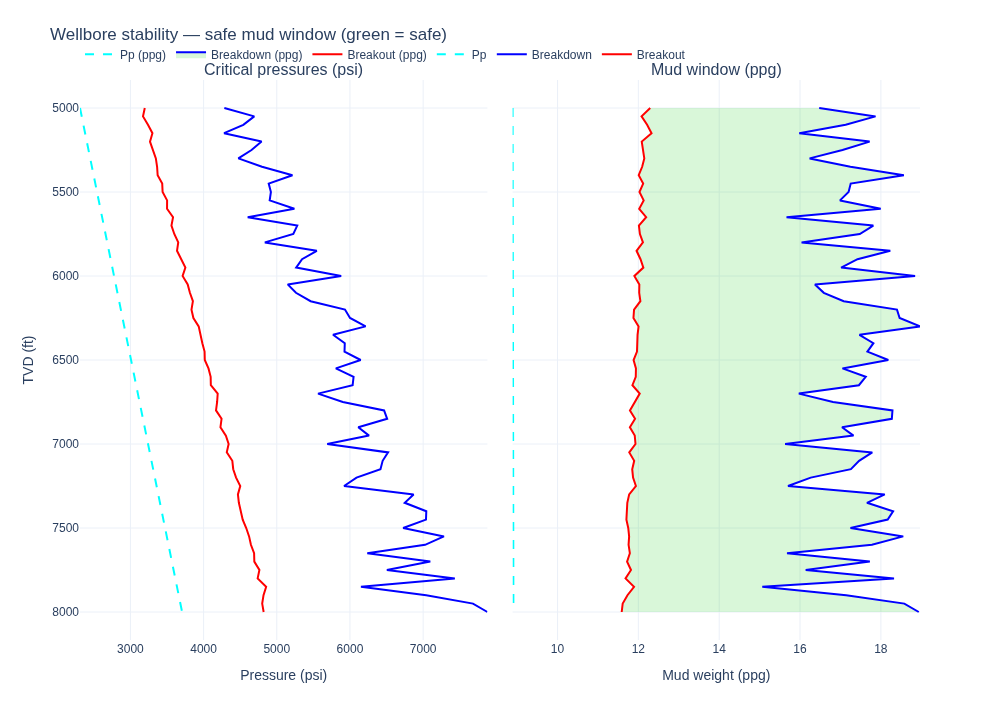

In [19]:
# QC — safe mud window in ppg (breakout = collapse/lower bound, breakdown = frac/upper bound)
fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.03,
                    subplot_titles=("Critical pressures (psi)", "Mud window (ppg)"))

# left: pressures in psi
depth_track(fig, 1, df["PW_BREAKOUT"], "red", "Breakout")
depth_track(fig, 1, df["PW_BREAKDOWN"], "blue", "Breakdown")
depth_track(fig, 1, df["PP"], "cyan", "Pp", dash="dash")

# right: equivalent mud weight in ppg with safe window shaded
fig.add_trace(go.Scatter(x=df["MW_BREAKOUT_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="red"), name="Breakout (ppg)"),
              row=1, col=2)
fig.add_trace(go.Scatter(x=df["MW_BREAKDOWN_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="blue"), name="Breakdown (ppg)",
                         fill="tonextx", fillcolor="rgba(0,200,0,0.15)"),
              row=1, col=2)
fig.add_trace(go.Scatter(x=df["PP_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="cyan", dash="dash"), name="Pp (ppg)"),
              row=1, col=2)

fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_xaxes(title_text="Pressure (psi)", row=1, col=1)
fig.update_xaxes(title_text="Mud weight (ppg)", row=1, col=2)
fig.update_layout(height=720, width=1000, template="plotly_white",
                  title="Wellbore stability — safe mud window (green = safe)",
                  margin=dict(t=80),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02))
fig.show()

## 10. Master composite QC log

All key MEM outputs on a single depth track for final review.

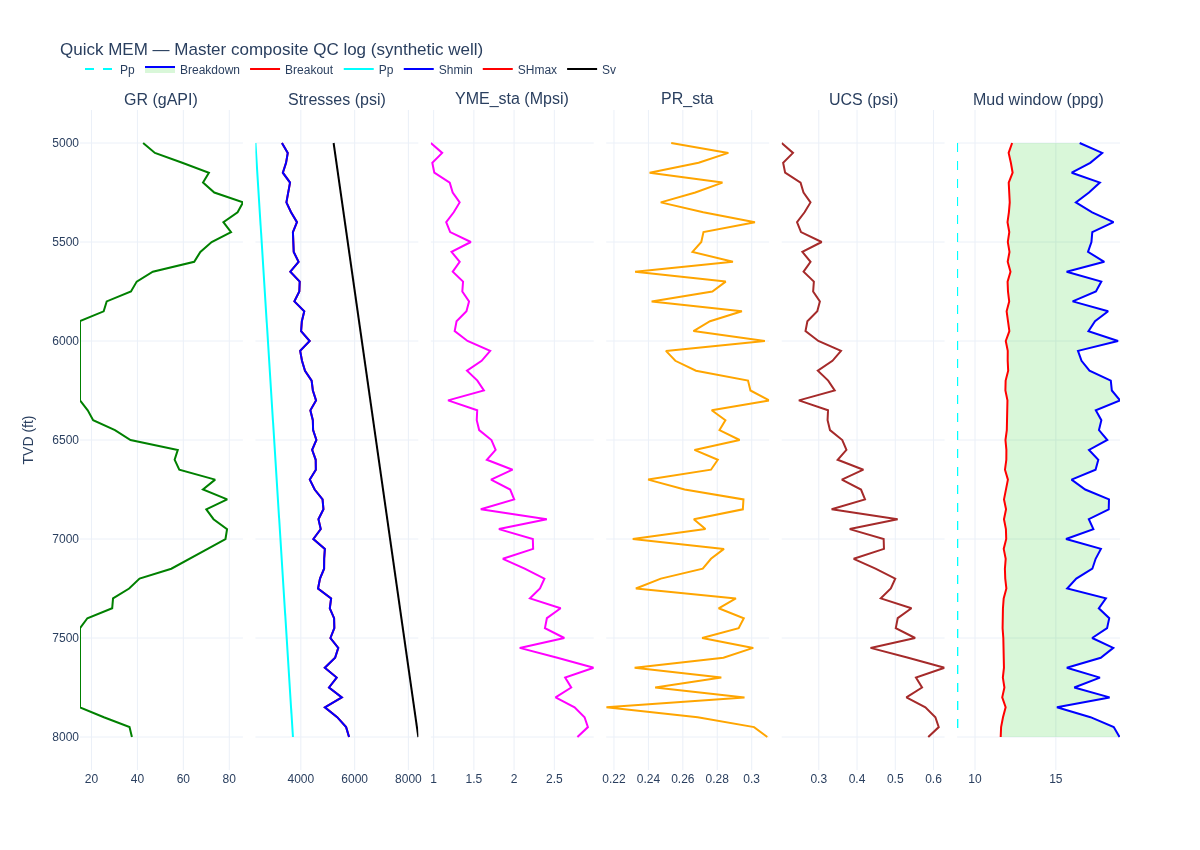

In [20]:
# Master composite QC log — every key MEM output on one figure
fig = make_subplots(
    rows=1, cols=6, shared_yaxes=True, horizontal_spacing=0.012,
    subplot_titles=("GR (gAPI)", "Stresses (psi)", "YME_sta (Mpsi)",
                    "PR_sta", "UCS (psi)", "Mud window (ppg)"),
)

depth_track(fig, 1, df["GR"], "green", "GR", showlegend=False)

depth_track(fig, 2, df["SV"], "black", "Sv")
depth_track(fig, 2, df["SHMAX"], "red", "SHmax")
depth_track(fig, 2, df["SHMIN"], "blue", "Shmin")
depth_track(fig, 2, df["PP"], "cyan", "Pp")

depth_track(fig, 3, df["YME_STA_Mpsi"], "magenta", "YME_sta", showlegend=False)
depth_track(fig, 4, df["PR_STA"], "orange", "PR_sta", showlegend=False)
depth_track(fig, 5, df["UCS"], "brown", "UCS", showlegend=False)

fig.add_trace(go.Scatter(x=df["MW_BREAKOUT_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="red"), name="Breakout"), row=1, col=6)
fig.add_trace(go.Scatter(x=df["MW_BREAKDOWN_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="blue"), name="Breakdown",
                         fill="tonextx", fillcolor="rgba(0,200,0,0.15)"), row=1, col=6)
fig.add_trace(go.Scatter(x=df["PP_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="cyan", dash="dash"), name="Pp"), row=1, col=6)

fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(
    height=850, width=1200, template="plotly_white",
    title="Quick MEM — Master composite QC log (synthetic well)",
    legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0),
    margin=dict(t=110),
)
fig.show()

## Done

The DataFrame `df` holds a complete 1-D MEM at every depth sample. Export with:

```python
df.to_csv("quick_mem_results.csv", index=False)
```